# DuckDB SQL → Plot Pattern (Clean Teaching Version)

Pattern used throughout:
1) Write SQL
2) Execute via DuckDB
3) Visualize with a small helper

This avoids magic commands and keeps focus on **SQL → Insight**.

## Setup

In [1]:

import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()

# Load CSV (make sure insurance.csv is in your working directory)
con.execute("""
CREATE OR REPLACE TABLE insurance AS
SELECT * FROM read_csv_auto('insurance.csv');
""")

con.execute("SELECT * FROM insurance LIMIT 5").df()


,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,True,southwest,16884.92400
1,18,male,33.770,1,False,southeast,1725.55230
2,28,male,33.000,3,False,southeast,4449.46200
3,33,male,22.705,0,False,northwest,21984.47061
4,32,male,28.880,0,False,northwest,3866.85520


## Helper: sqlplot(query, kind)

A tiny wrapper so students stay SQL-first.
No colors specified (matplotlib default).

In [9]:

def sqlplot(query, kind="bar", x=None, y=None, bins=20):
    df = con.execute(query).df()
    plt.figure()

    # -----------------------
    # BAR
    # -----------------------
    if kind == "bar":
        if x is None or y is None:
            x, y = df.columns[0], df.columns[1]
        plt.bar(df[x], df[y])
        plt.xlabel(x)
        plt.ylabel(y)

    # -----------------------
    # HORIZONTAL BAR (better labels)
    # -----------------------
    elif kind == "barh":
        if x is None or y is None:
            x, y = df.columns[1], df.columns[0]
        plt.barh(df[y], df[x])
        plt.xlabel(x)
        plt.ylabel(y)

    # -----------------------
    # HISTOGRAM
    # -----------------------
    elif kind == "hist":
        col = x if x else df.columns[0]
        plt.hist(df[col], bins=bins)
        plt.xlabel(col)
        plt.ylabel("count")

    # -----------------------
    # SCATTER
    # -----------------------
    elif kind == "scatter":
        if x is None or y is None:
            x, y = df.columns[0], df.columns[1]
        plt.scatter(df[x], df[y])
        plt.xlabel(x)
        plt.ylabel(y)

    # -----------------------
    # LINE (time series)
    # -----------------------
    elif kind == "line":
        if x is None or y is None:
            x, y = df.columns[0], df.columns[1]
        plt.plot(df[x], df[y])
        plt.xlabel(x)
        plt.ylabel(y)

    # -----------------------
    # PIE (proportion)
    # -----------------------
    elif kind == "pie":
        if x is None or y is None:
            x, y = df.columns[0], df.columns[1]
        plt.pie(df[y], labels=df[x], autopct='%1.1f%%')
        plt.title("Distribution")

    # -----------------------
    # BOX (distribution insight)
    # -----------------------
    elif kind == "box":
        col = x if x else df.columns[0]
        plt.boxplot(df[col])
        plt.ylabel(col)

    else:
        raise ValueError("Unsupported kind")

    plt.title("Result")
    plt.tight_layout()
    plt.show()

## 1) Distribution of Charges

**Business question:** How are costs distributed?

**SQL:** select raw values to inspect distribution.

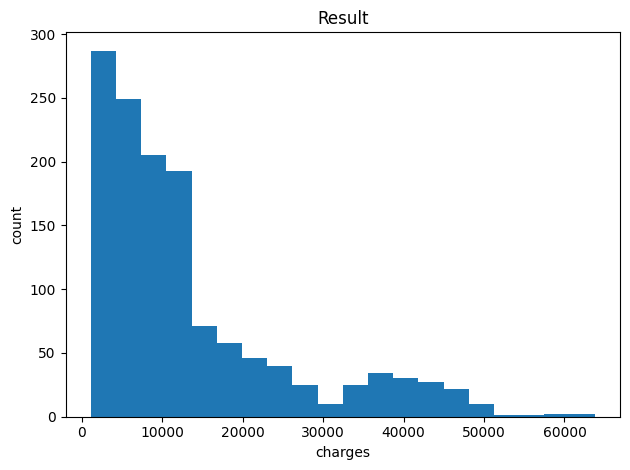

In [10]:

query = """
SELECT charges
FROM insurance
"""
sqlplot(query, kind="hist", x="charges", bins=20)


query = """
SELECT charges
FROM insurance
"""
sqlplot(query, kind="pie", x="charges", bins=20)


## 2) Charges by Smoker

**Business question:** Do smokers cost more?

**SQL pattern:** aggregation (GROUP BY).

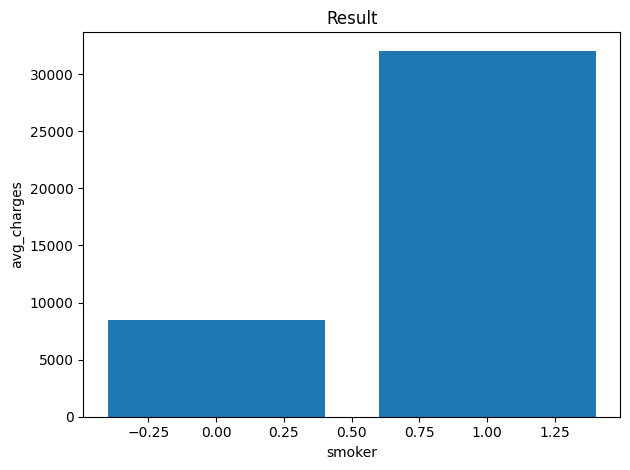

In [15]:
query = """
SELECT smoker, AVG(charges) AS avg_charges
FROM insurance
GROUP BY smoker
"""
sqlplot(query, kind="bar", x="smoker", y="avg_charges")

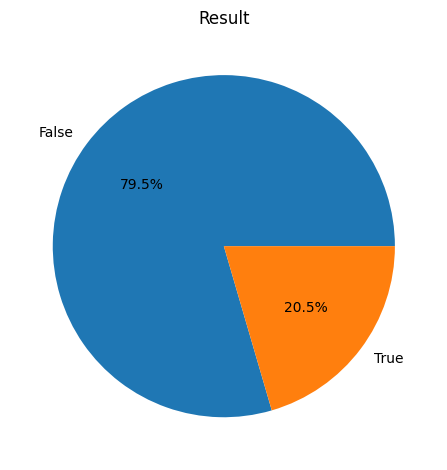

In [17]:
# Smoker Distribution
# What percentage of customers are smokers vs non-smokers?

# Business Insight
#	•	Shows population composition
#	•	Typically:
#	•	non-smokers dominate
#	•	smokers are a smaller segment

sqlplot("""
SELECT smoker, COUNT(*) AS cnt
FROM insurance
GROUP BY smoker
""", kind="pie")

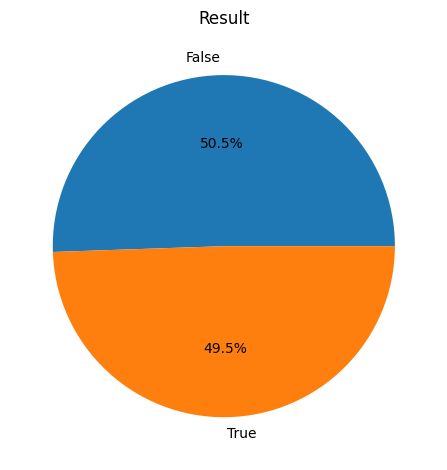

In [18]:
#  Revenue Share by Smoker
# Deeper Insight
#	•	now pie shows financial impact, not population
#	•	smokers may:
#	•	   be fewer
#	•	   but contribute disproportionately to total cost

sqlplot("""
SELECT smoker, SUM(charges) AS total_charges
FROM insurance
GROUP BY smoker
""", kind="pie")

## 3) Charges by Region

**Business question:** Which regions are more expensive?

**SQL pattern:** aggregation by segment.

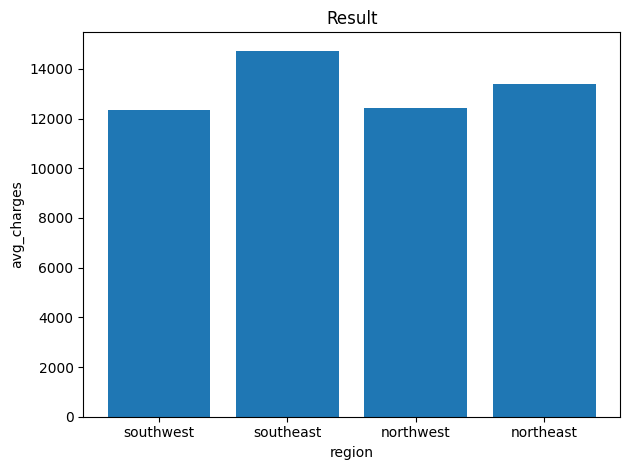

In [11]:

query = """
SELECT region, AVG(charges) AS avg_charges
FROM insurance
GROUP BY region
"""
sqlplot(query, kind="bar", x="region", y="avg_charges")


## 4) Age vs Charges

**Business question:** Does age relate to cost?

**SQL pattern:** select two columns for relationship.

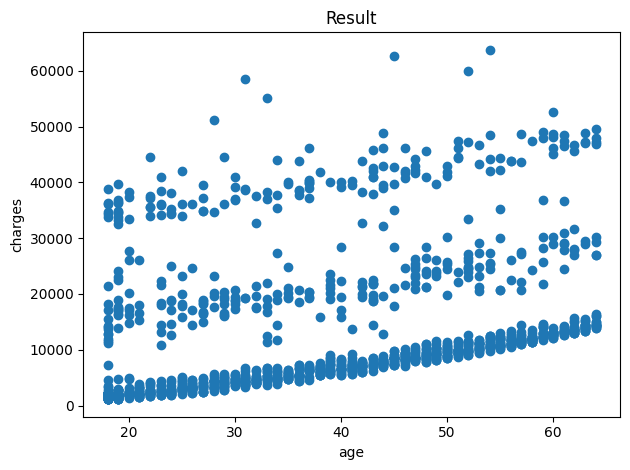

In [12]:

query = """
SELECT age, charges
FROM insurance
"""
sqlplot(query, kind="scatter", x="age", y="charges")


## 5) BMI vs Charges

**Business question:** Does BMI relate to cost?

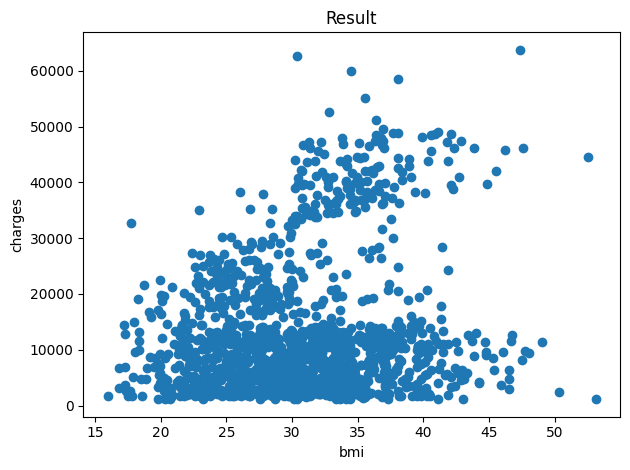

In [13]:

query = """
SELECT bmi, charges
FROM insurance
"""
sqlplot(query, kind="scatter", x="bmi", y="charges")


## 6) Children vs Charges

**Business question:** Does family size affect cost?

**SQL pattern:** aggregation by discrete group.

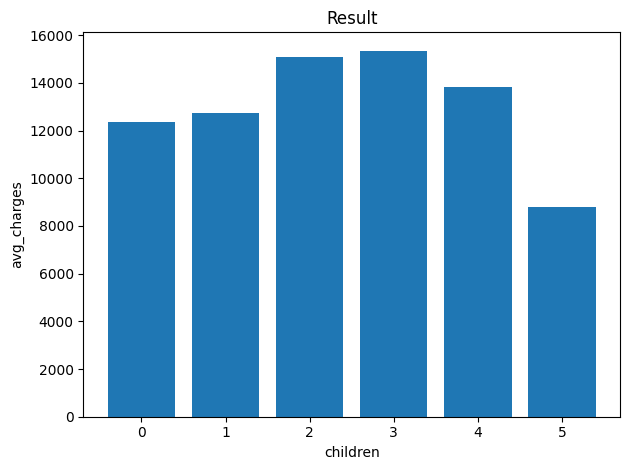

In [14]:

query = """
SELECT children, AVG(charges) AS avg_charges
FROM insurance
GROUP BY children
"""
sqlplot(query, kind="bar", x="children", y="avg_charges")


## Wrap-Up

Pattern to remember:

SQL → Result → Plot → Insight → Decision

Keep visualization simple; focus on the **question and interpretation**.